In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from visual_functions import expected_calibration_error, plot_model_metrics, analyze_line_movement_perf, plot_juice_histogram
from utils import calc_net_odds, print_gender_accuracy

from sklearn.metrics import accuracy_score, f1_score, brier_score_loss

In [ ]:
df_train_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_open.csv')
df_train_close1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_close1.csv')
df_train_close2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_close2.csv')

df_test_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_open.csv')
df_test_close1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close1.csv')
df_test_close2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close2.csv')


In [ ]:
for c in df_train_open.columns:
    print(c)

In [9]:
df_vegas = pd.concat([df_train_open, df_test_open], ignore_index=True)[['Date','winner', 'fighter_red', 'fighter_blue', 'weight_class', 
                                                                        'date', 'open_red', 'open_blue', 'close1_red', 'close1_blue', 'close2_red', 'close2_blue',
                                                                        'proba_fair_open_red', 'proba_fair_open_blue', 'proba_fair_close1_red', 'proba_fair_close1_blue', 'proba_fair_close2_red', 'proba_fair_close2_blue']]



In [4]:
def vegas_acc_over_time(df_, odds_type, acc_type='accuracy', by_year=True):
    df = df_.copy()
    df = df.sort_values('Date', ascending=True)
    df['vegas_pred'] = np.where(df[f'{odds_type}_red'] < df[f'{odds_type}_blue'], 1, 0)

    accs = []
    if by_year:
        df['year'] = pd.to_datetime(df['Date']).dt.year
        year_groups = df.groupby('year')
        for year, group in year_groups:

            if acc_type == 'accuracy':
                acc = accuracy_score(group['winner'], group['vegas_pred'])
            
            elif acc_type == 'f1':
                acc = f1_score(group['winner'], group['vegas_pred'])
            
            elif acc_type == 'brier':
                acc = brier_score_loss(group['winner'], group[f'proba_fair_{odds_type}_red'])
            
            accs.append((year, acc))
    
    else:
        event_groups = df.groupby('Date')
        for date, group in event_groups:
            acc = accuracy_score(group['winner'], group['vegas_pred'])
            accs.append((date, acc))
    return accs


def plot_vegas_acc(df_, odds_type, acc_type='accuracy', by_year=True):
    accs = vegas_acc_over_time(df_, odds_type, acc_type, by_year)

    fig, ax = plt.subplots(ncols=2, figsize=(10,4))
    ax[0].plot([x[0] for x in accs], [x[1] for x in accs], marker='o')
    ax[0].set_title(f'Vegas Accuracy Over Time ({acc_type})')
    ax[0].set_xlabel('Year' if by_year else 'Date')
    ax[0].set_ylabel(f'{acc_type.capitalize()}')

    diffs = [accs[i][1] - accs[i-1][1] for i in range(1, len(accs))]
    ax[1].plot([x[0] for x in accs][1:], diffs, marker='o')
    ax[1].set_title(f'Vegas Accuracy Over Time ({acc_type})')
    ax[1].set_xlabel('Year' if by_year else 'Date')
    ax[1].set_ylabel(f'{acc_type.capitalize()}')
    
    plt.tight_layout()
    plt.show()

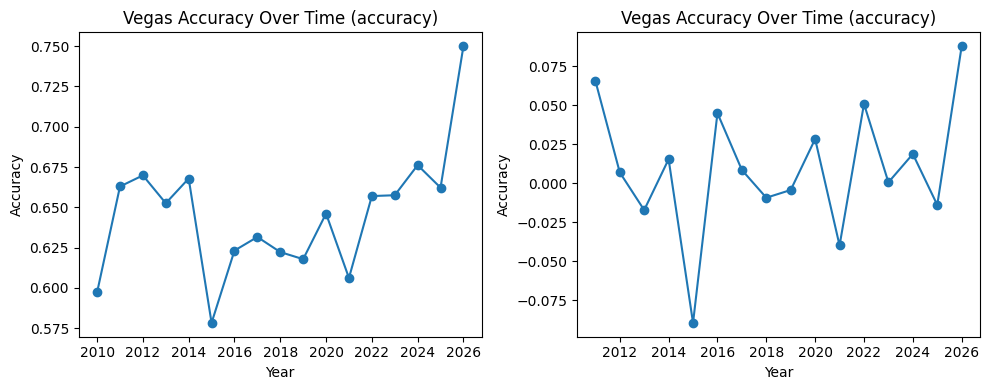

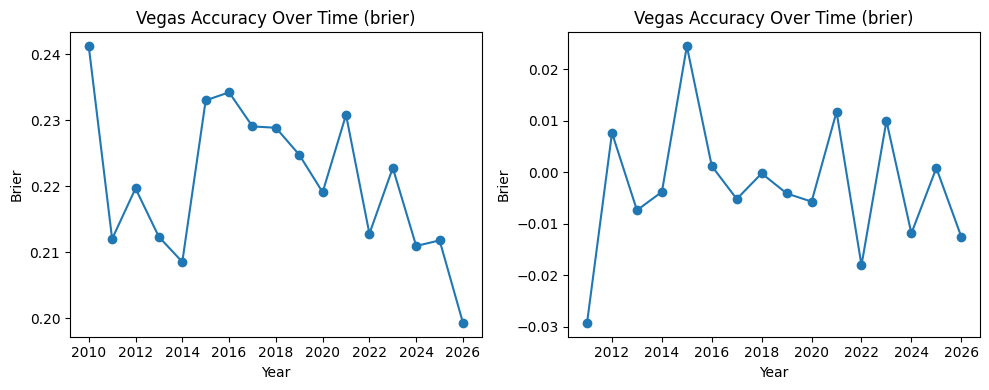

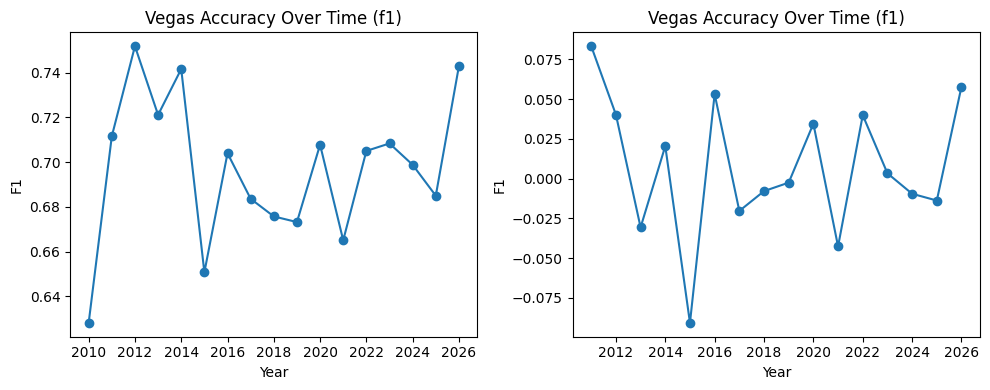

In [5]:
plot_vegas_acc(df_vegas, 'open', acc_type='accuracy', by_year=True)
plot_vegas_acc(df_vegas, 'open', acc_type='brier', by_year=True)
plot_vegas_acc(df_vegas, 'open', acc_type='f1', by_year=True)


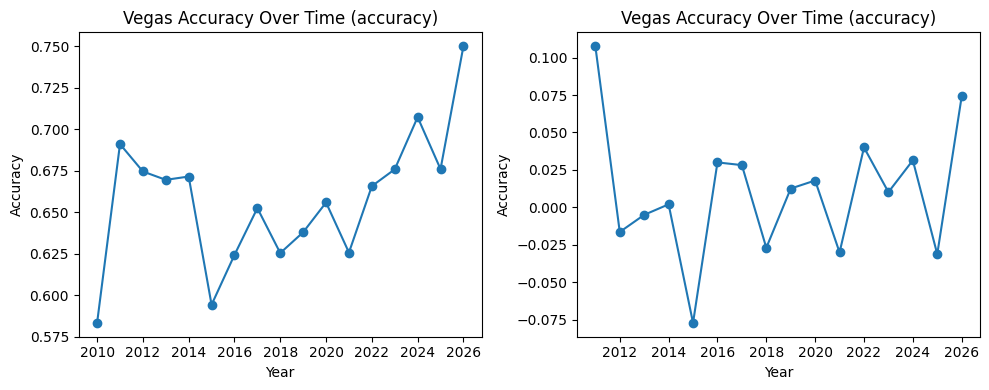

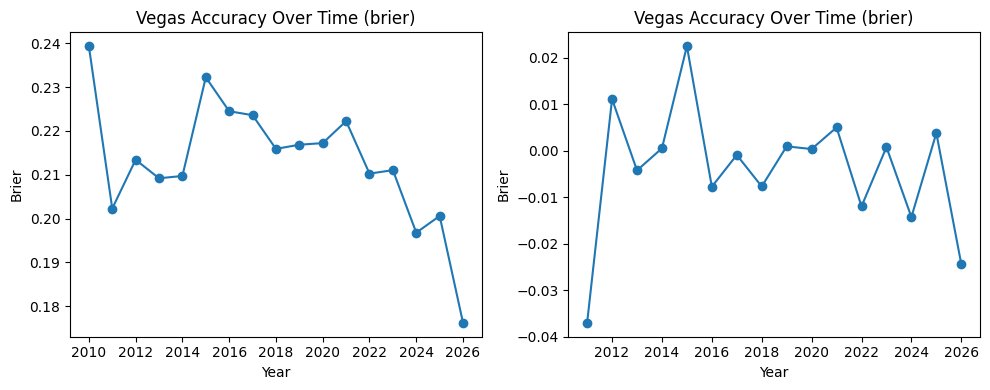

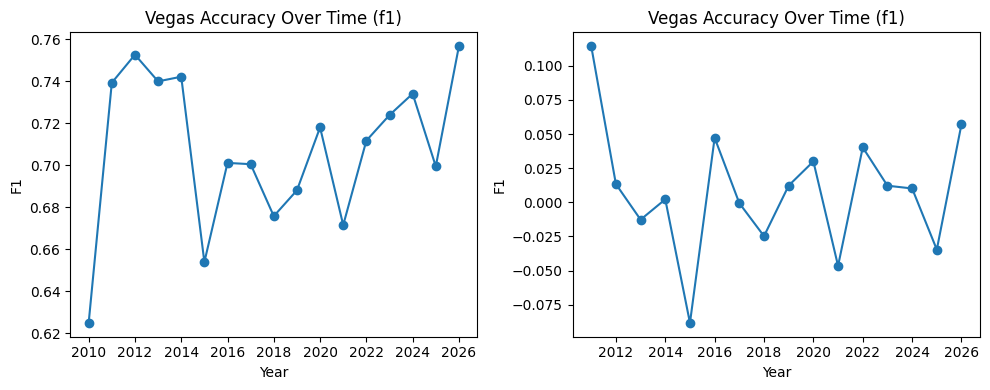

In [36]:
plot_vegas_acc(df_vegas, 'close1', acc_type='accuracy', by_year=True)
plot_vegas_acc(df_vegas, 'close1', acc_type='brier', by_year=True)
plot_vegas_acc(df_vegas, 'close1', acc_type='f1', by_year=True)


In [7]:
def plot_vegas_metrics(df_, odds_type):
    df = df_.copy()
    
    df['vegas_pred'] = np.where(df[f'{odds_type}_red'] < df[f'{odds_type}_blue'], 1, 0)
    df['vegas_pred_fair_proba'] = np.where(df[f'{odds_type}_red'] < df[f'{odds_type}_blue'], df[f'proba_fair_{odds_type}_red'], df[f'proba_fair_{odds_type}_blue'])
    
    expected_calibration_error(df['winner'].values, df[f'proba_fair_{odds_type}_red'].values, n_bins=20)
    plot_model_metrics(df['winner'].values, df['vegas_pred'].values, df[f'proba_fair_{odds_type}_red'].values)
    
    print(f"Vegas Accuracy ({odds_type}):", accuracy_score(df['winner'].values, df['vegas_pred'].values))
    print(f"Vegas F1 Score ({odds_type}):", f1_score(df['winner'].values, df['vegas_pred'].values))
    print(f"Vegas Brier Score Loss ({odds_type}):", brier_score_loss(df['winner'].values, df[f'proba_fair_{odds_type}_red'].values))

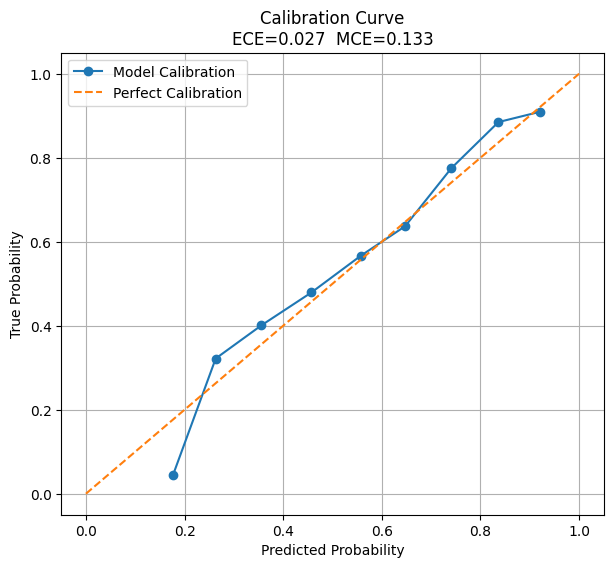

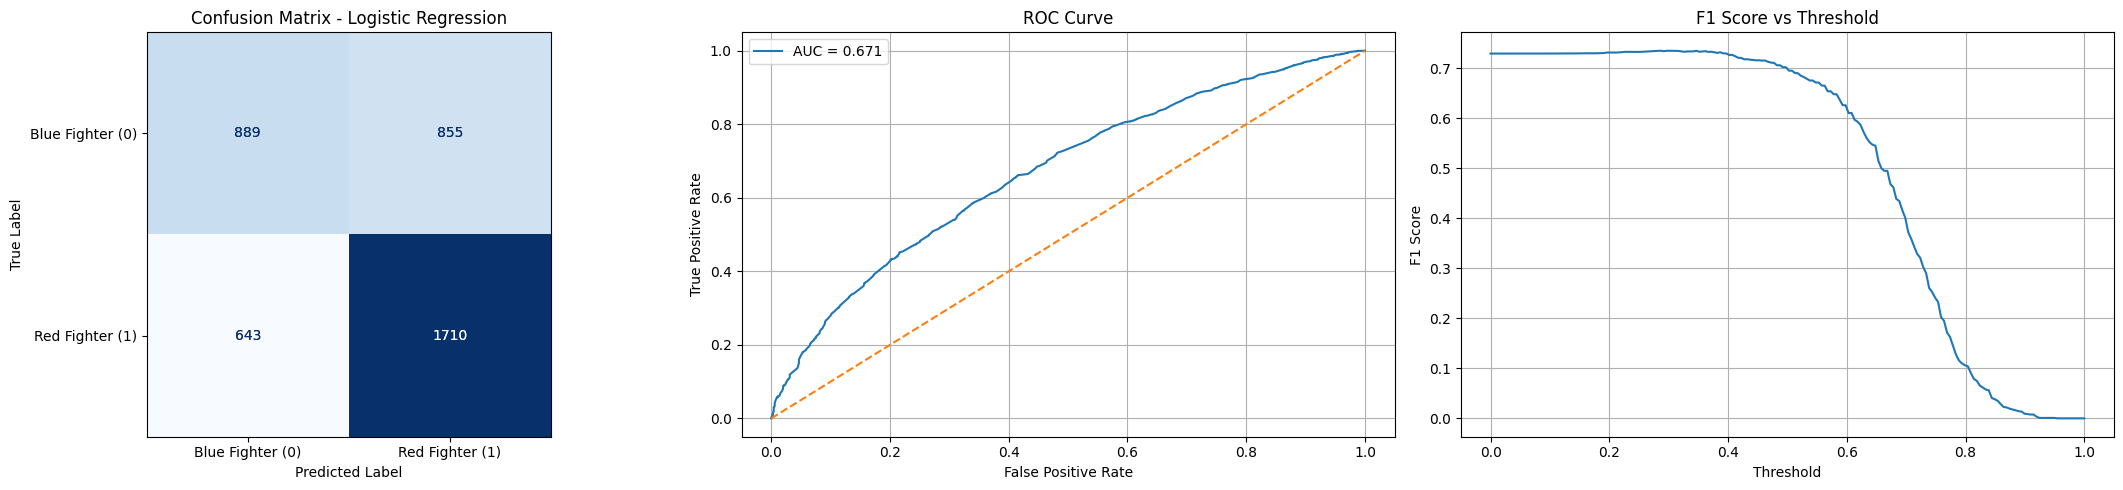

Vegas Accuracy (open): 0.6343666097144252
Vegas F1 Score (open): 0.6954046360309069
Vegas Brier Score Loss (open): 0.2236124245023902


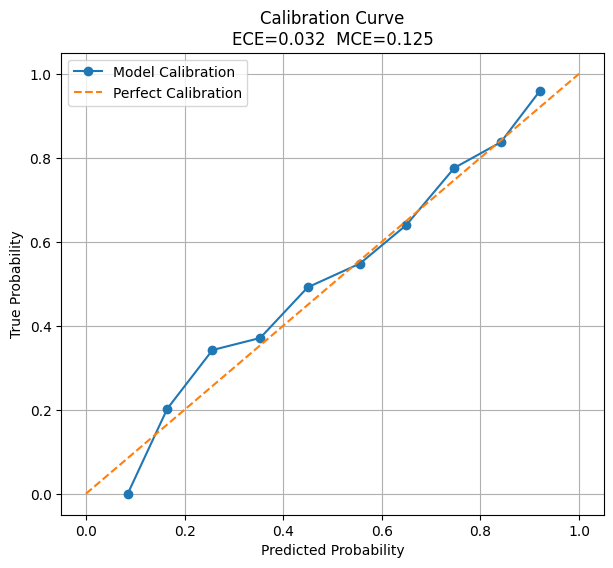

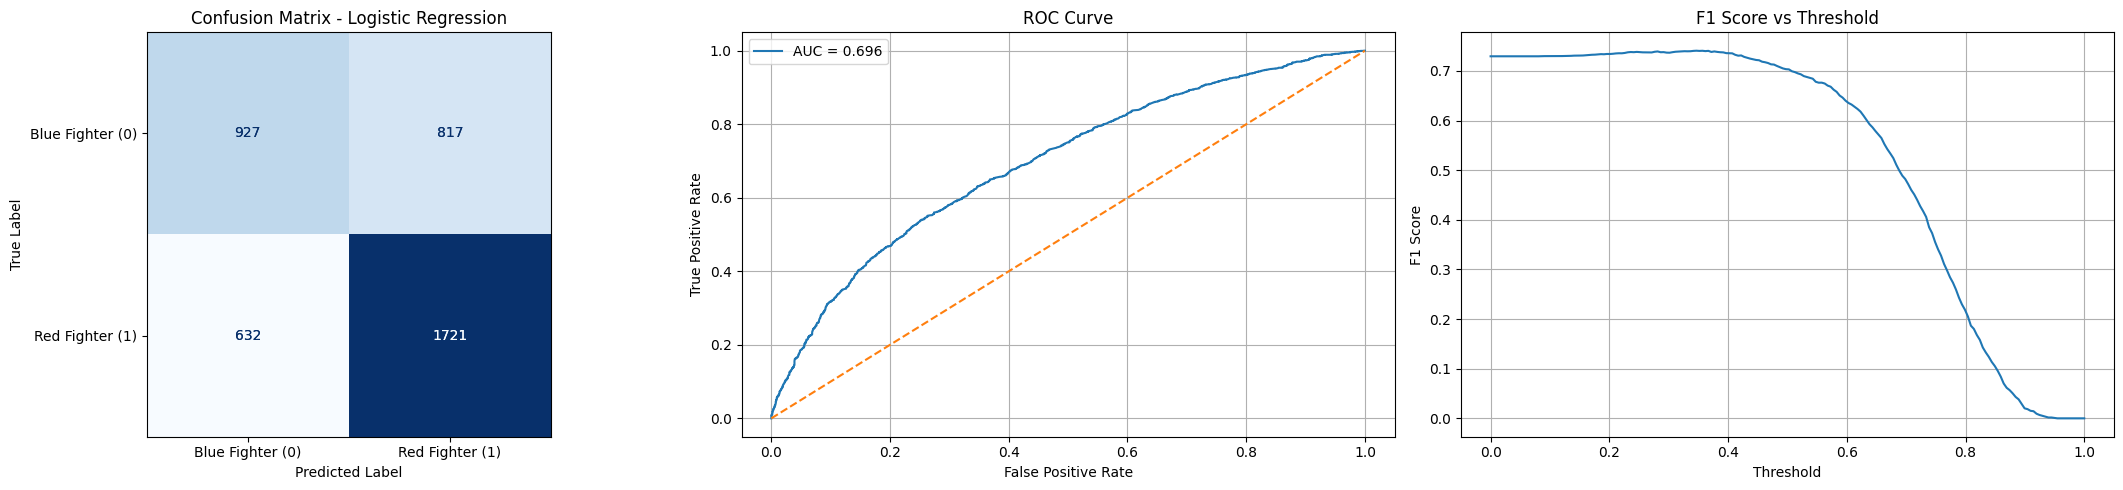

Vegas Accuracy (close1): 0.646326580424701
Vegas F1 Score (close1): 0.7037415661418933
Vegas Brier Score Loss (close1): 0.21729118665157302


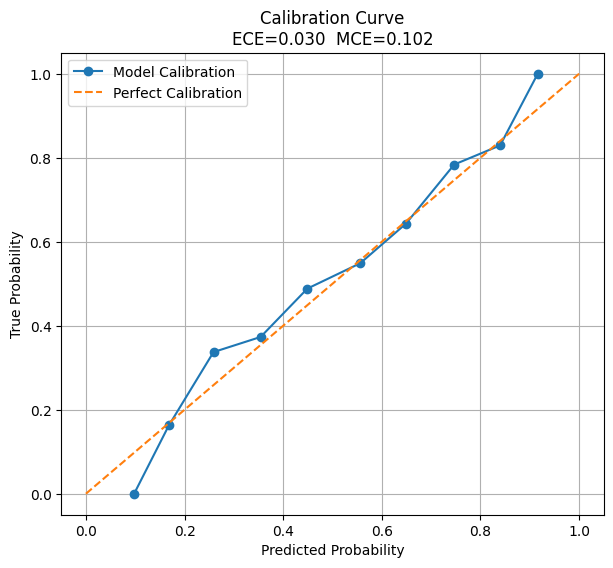

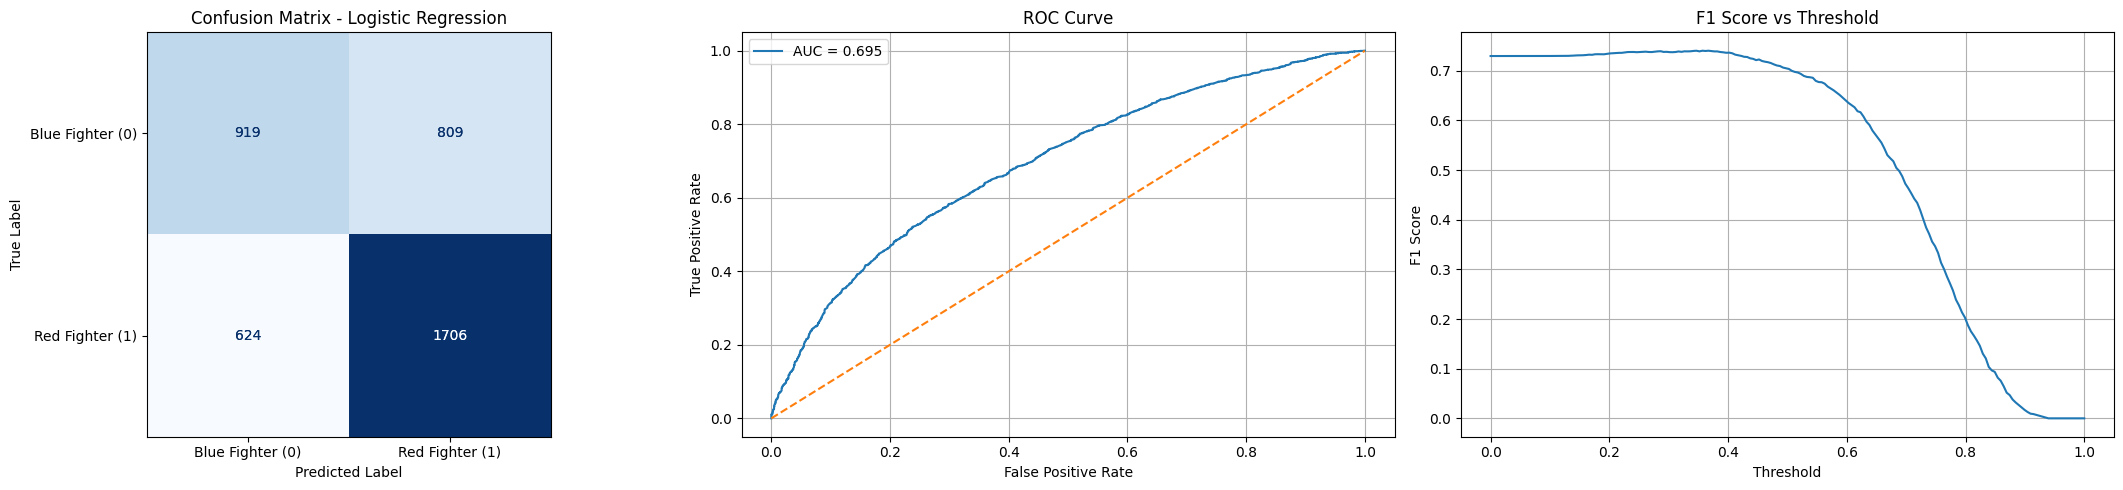

Vegas Accuracy (close2): 0.6468703794972893
Vegas F1 Score (close2): 0.7042311661506708
Vegas Brier Score Loss (close2): 0.21742433493949864


In [42]:
plot_vegas_metrics(df_train_open, 'open')
plot_vegas_metrics(df_train_close1, 'close1')   
plot_vegas_metrics(df_train_close2, 'close2')

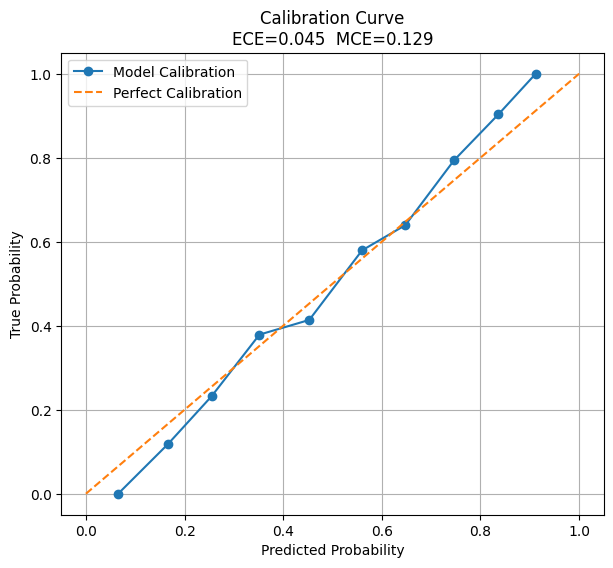

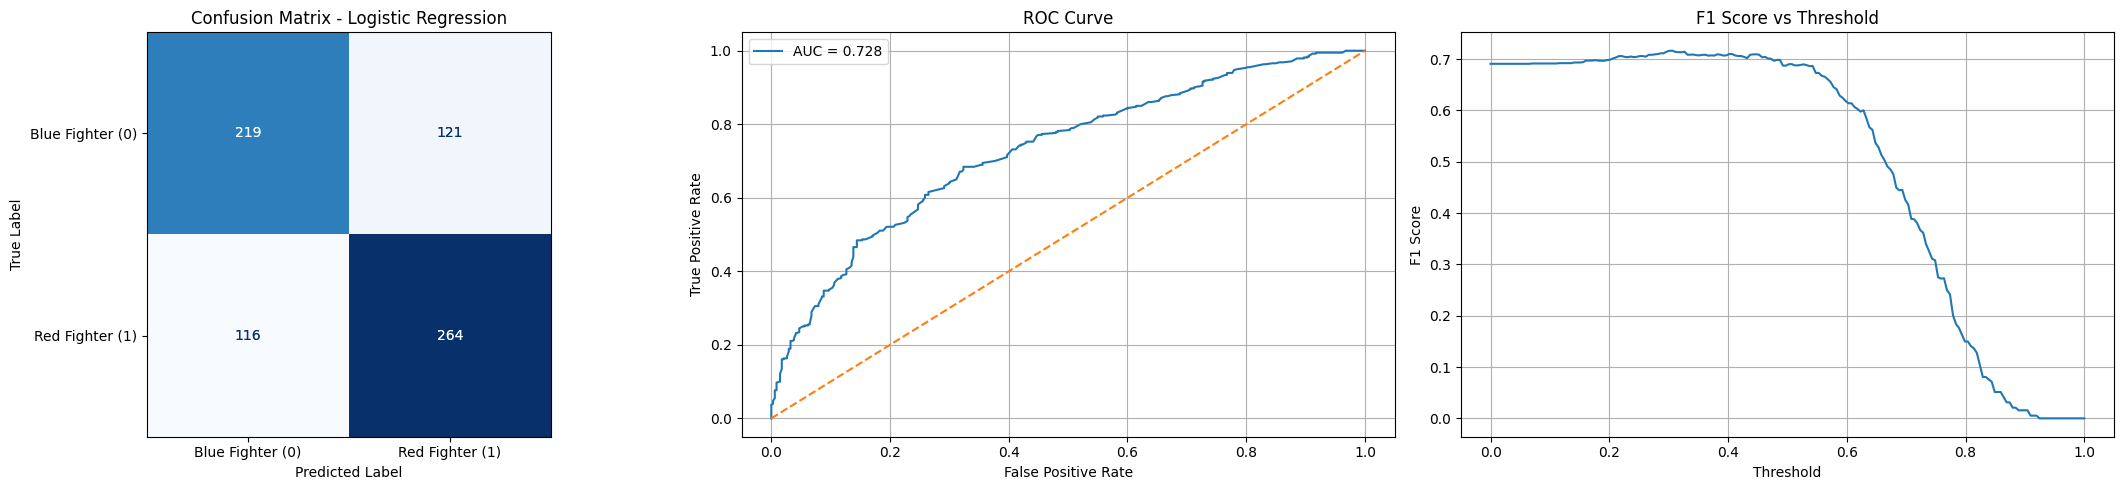

Vegas Accuracy (open): 0.6708333333333333
Vegas F1 Score (open): 0.6901960784313725
Vegas Brier Score Loss (open): 0.2101238669638142


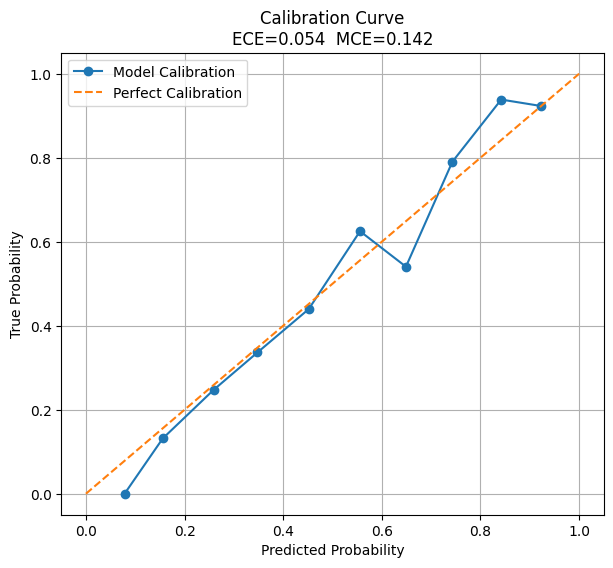

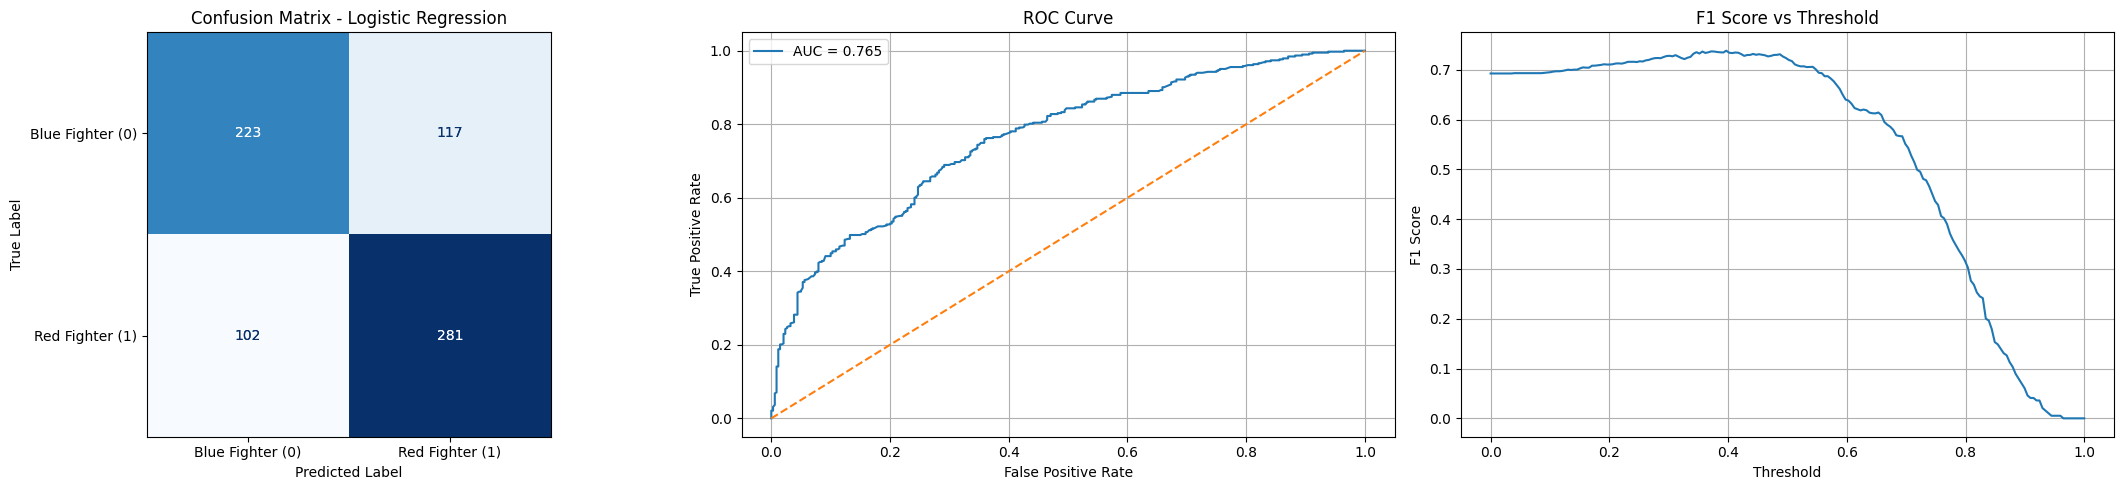

Vegas Accuracy (close1): 0.6970954356846473
Vegas F1 Score (close1): 0.7195902688860435
Vegas Brier Score Loss (close1): 0.19717200657219433


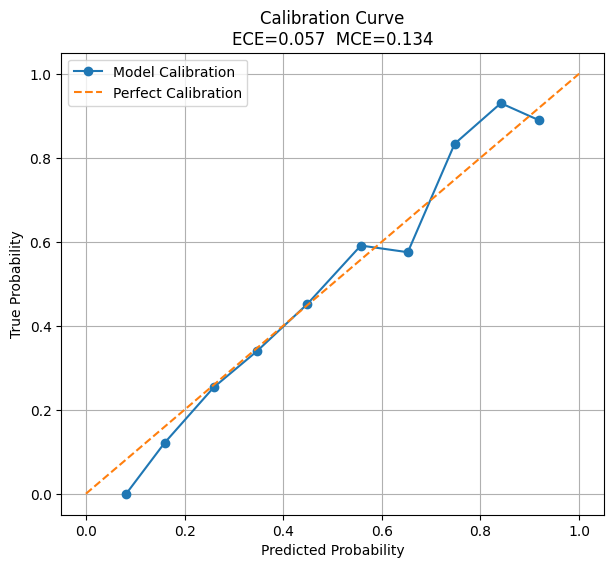

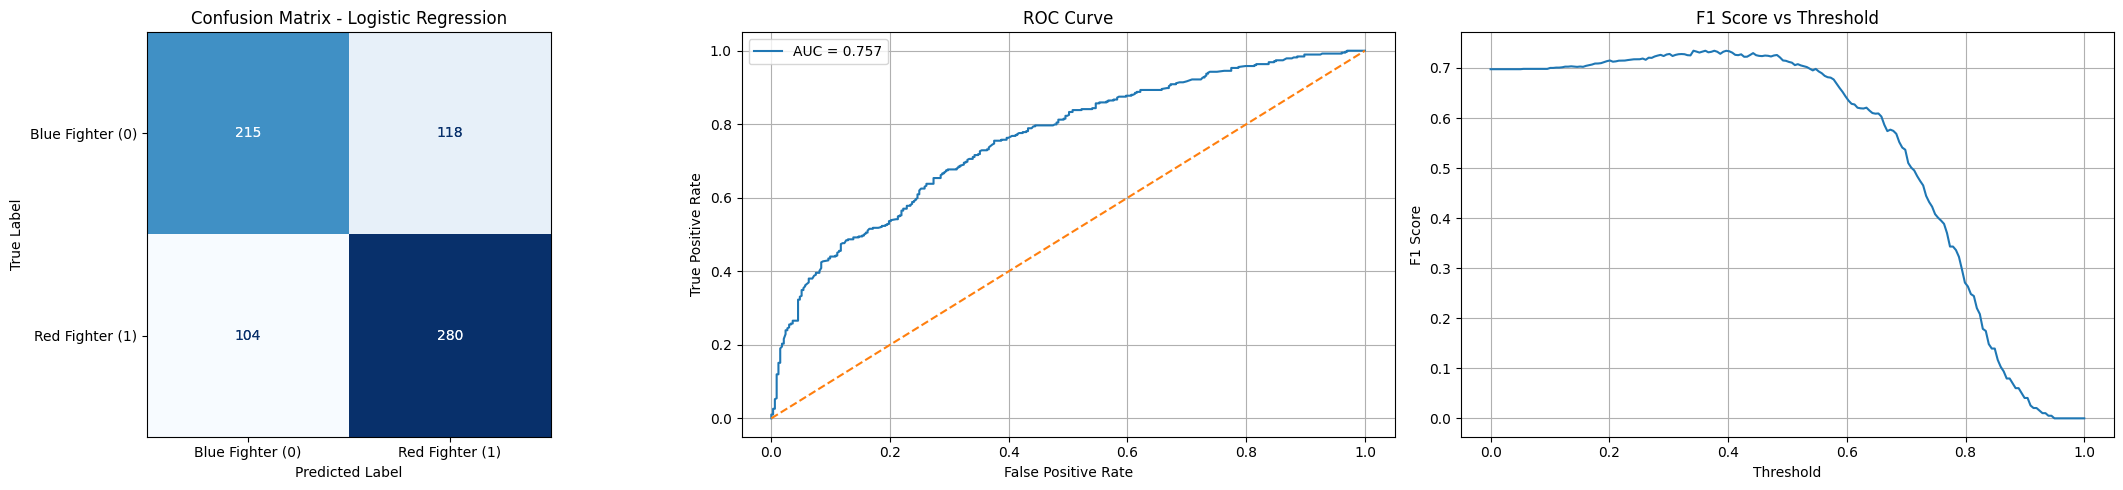

Vegas Accuracy (close2): 0.6903765690376569
Vegas F1 Score (close2): 0.7161125319693095
Vegas Brier Score Loss (close2): 0.20039974334376337


In [8]:
plot_vegas_metrics(df_test_open, 'open')
plot_vegas_metrics(df_test_close1, 'close1')   
plot_vegas_metrics(df_test_close2, 'close2')

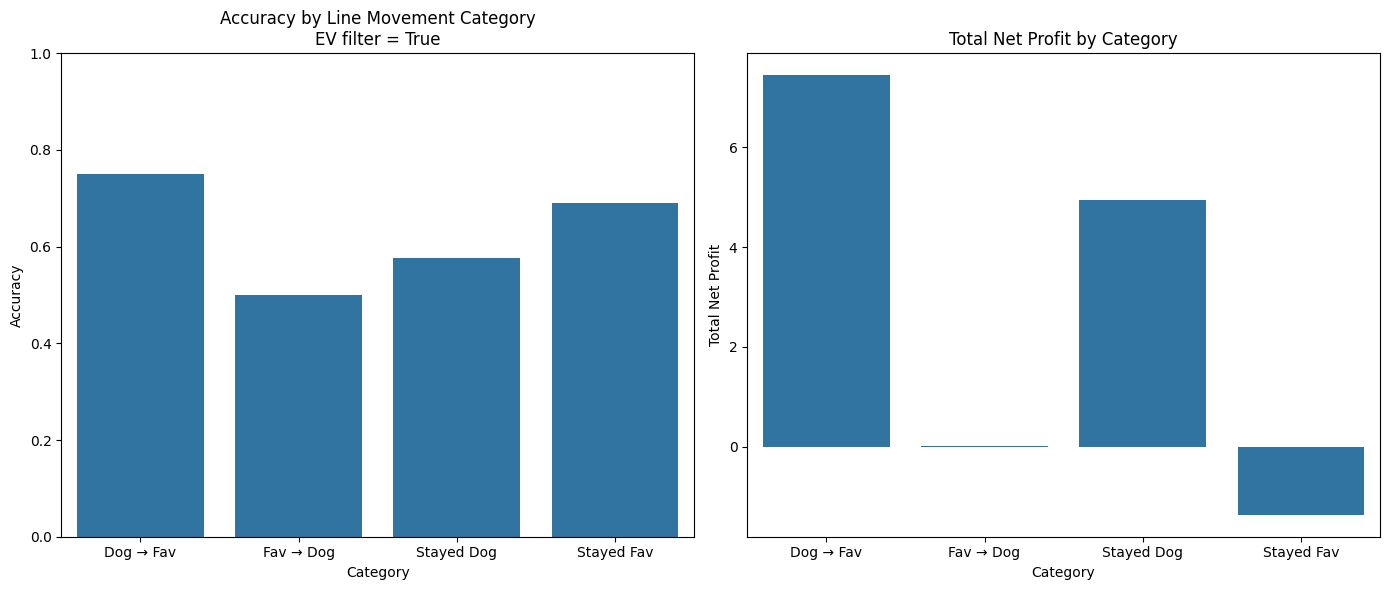

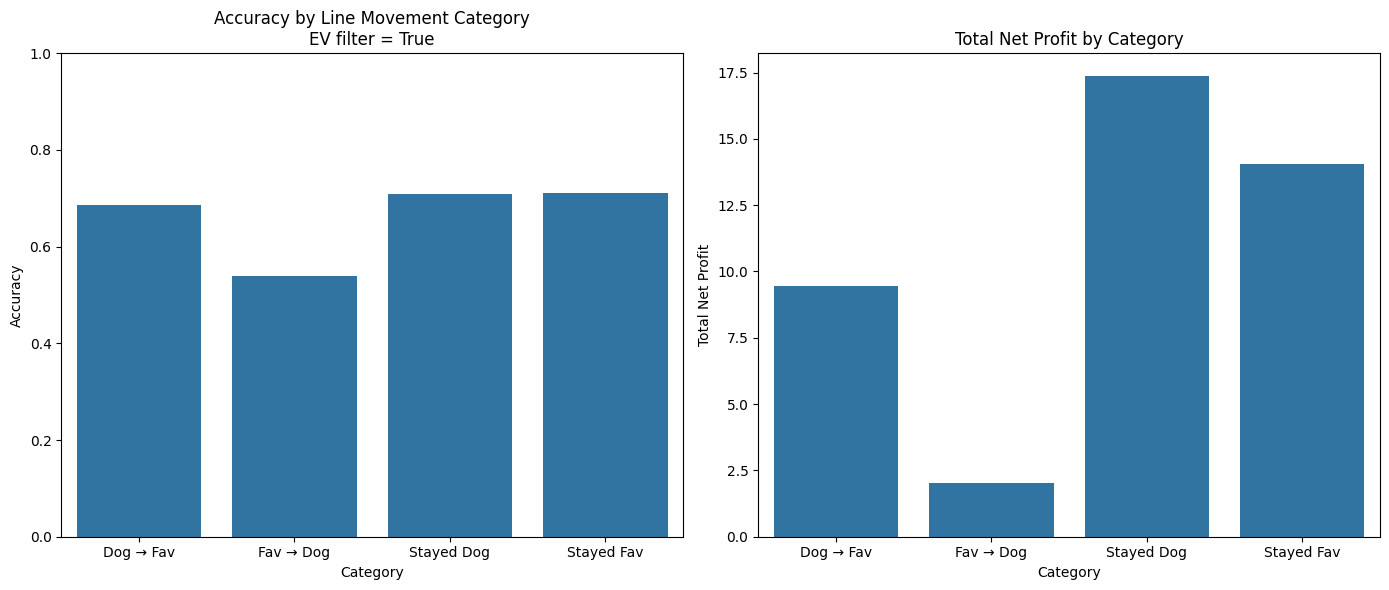

,movement_category,accuracy,n,total_profit,mean_EV
0,Dog → Fav,0.685185,54,9.467102,0.093323
1,Fav → Dog,0.538462,13,2.010000,0.425654
2,Stayed Dog,0.709677,31,17.363951,0.172836
3,Stayed Fav,0.710692,318,14.047038,0.070075


In [10]:

analyze_line_movement_perf(df_test_close1, 'close1')
analyze_line_movement_perf(df_test_close2, 'close2')

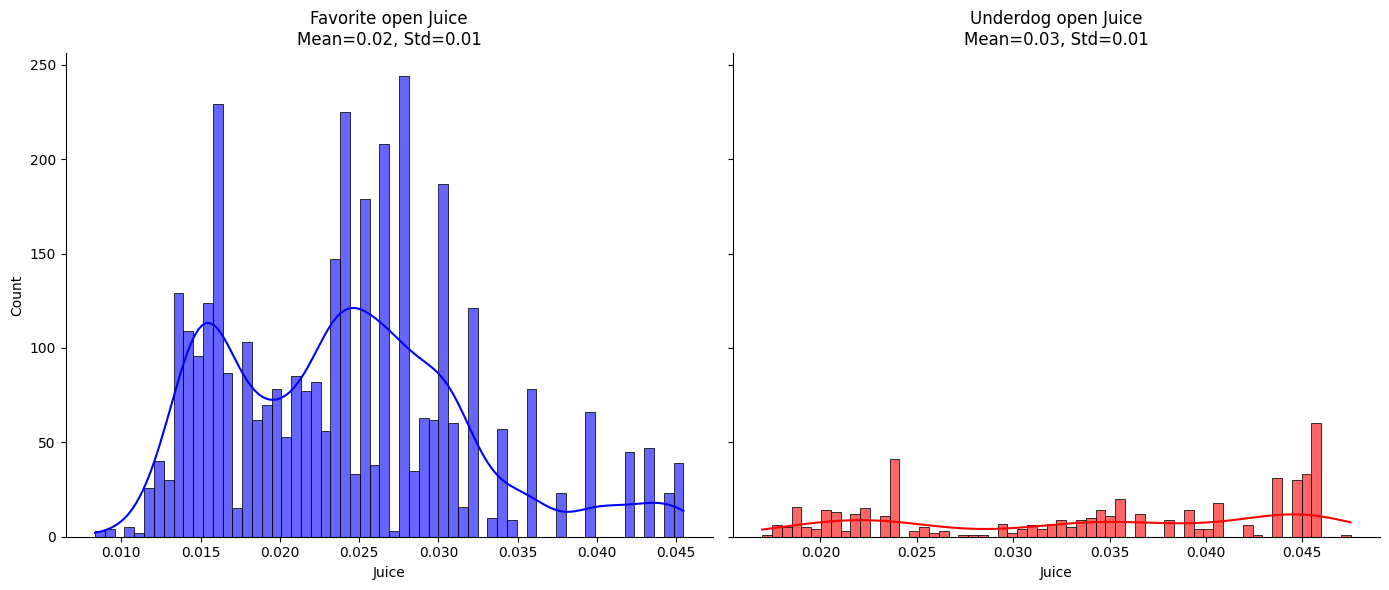

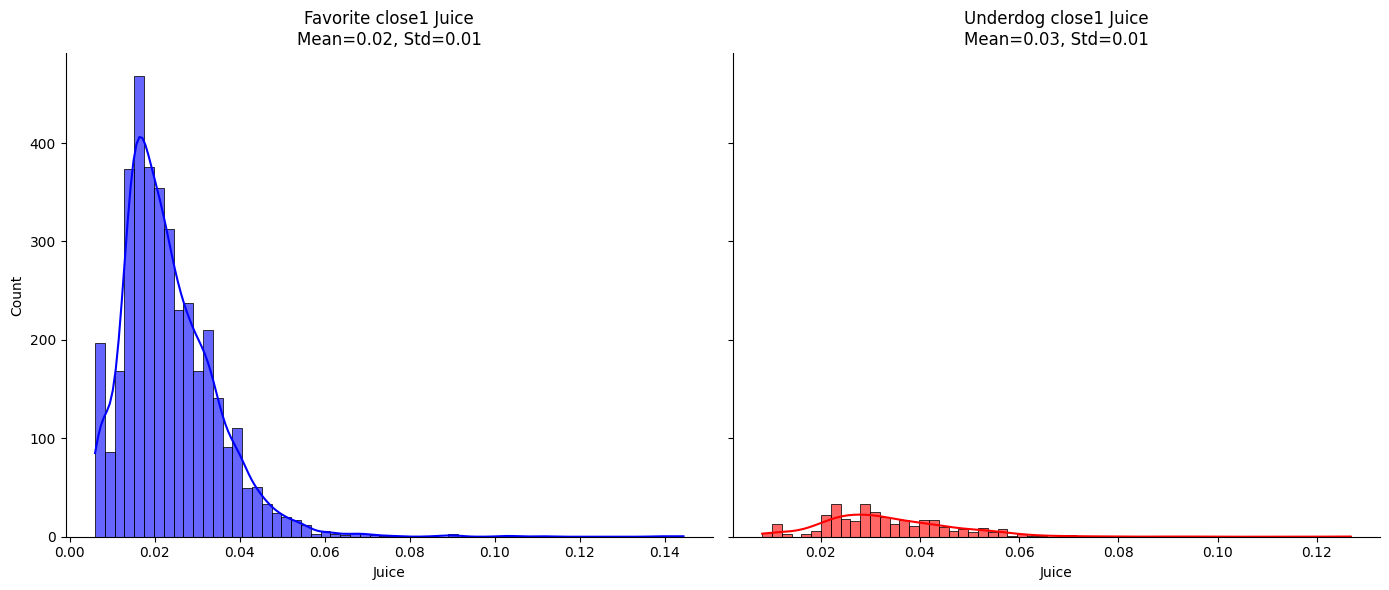

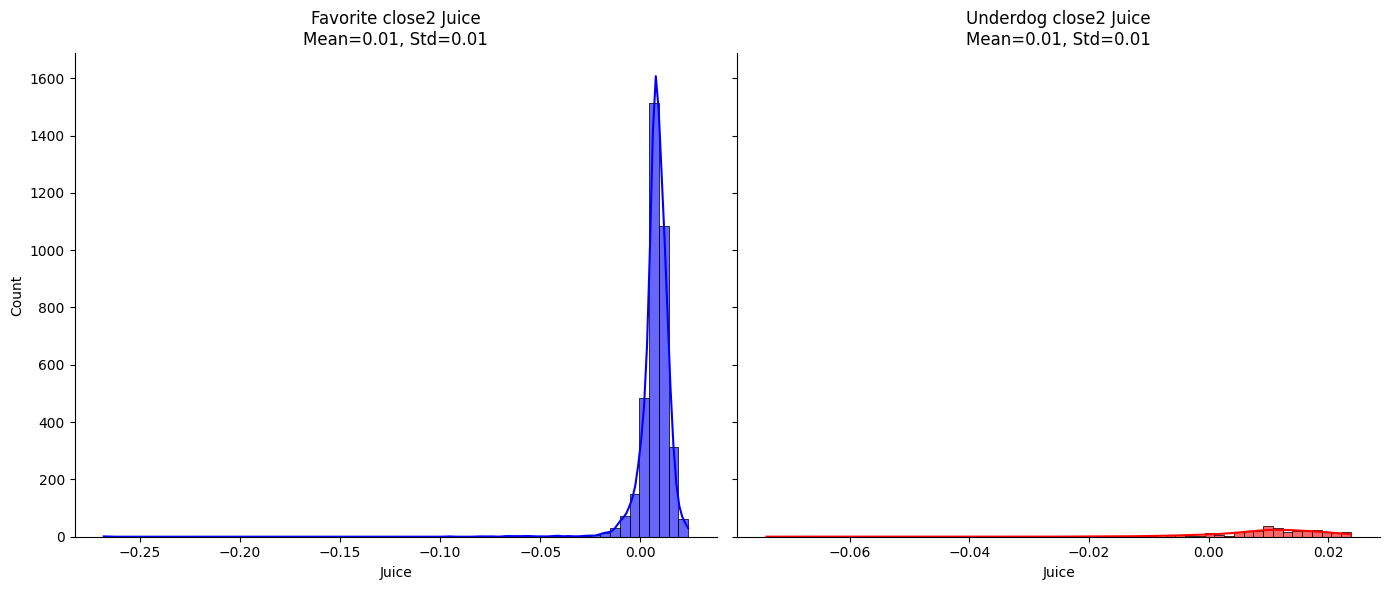

In [11]:
plot_juice_histogram(df_train_open, 'open')
plot_juice_histogram(df_train_close1, 'close1')
plot_juice_histogram(df_train_close2, 'close2')

In [37]:
calc_net_odds(df_test_open, 'open')
calc_net_odds(df_test_close1, 'close1')
calc_net_odds(df_test_close2, 'close2')

(556, 299) (955, 299)
Sum of decimal odds for favorite predictions (adjusted): 44.235808870659476
Sum of decimal odds for underdog predictions (adjusted): 35.12544524011814
Fav bets: 443 total, 326 correct, 117 incorrect, 73.59% correct
Dog bets: 113 total, 68 correct, 45 incorrect, 60.18% correct
(373, 299) (955, 299)
Sum of decimal odds for favorite predictions (adjusted): 23.11228298539723
Sum of decimal odds for underdog predictions (adjusted): 9.257346771212807
Fav bets: 327 total, 240 correct, 87 incorrect, 73.39% correct
Dog bets: 46 total, 27 correct, 19 incorrect, 58.70% correct
(554, 299) (955, 299)
Sum of decimal odds for favorite predictions (adjusted): 34.16733914625971
Sum of decimal odds for underdog predictions (adjusted): 11.693950709484692
Fav bets: 489 total, 348 correct, 141 incorrect, 71.17% correct
Dog bets: 65 total, 35 correct, 30 incorrect, 53.85% correct


In [39]:
print_gender_accuracy(df_test_open)
print_gender_accuracy(df_test_close1)     
print_gender_accuracy(df_test_close2)

Accuracy for Men weight classes:   0.690
Accuracy for Women weight classes: 0.716
Accuracy for Men weight classes:   0.692
Accuracy for Women weight classes: 0.716
Accuracy for Men weight classes:   0.691
Accuracy for Women weight classes: 0.710
